In [33]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [42]:
# Find all directories recursively under logs/unified
base_dir = Path(os.path.abspath('')) / 'logs' / 'unified'
scenario_folders = [p for p in base_dir.rglob('*') if p.is_dir()]
scenario_folders.sort()
# Remove all folders that still have other child folders
scenario_folders = [p for p in scenario_folders if not any([p.is_dir() for p in p.iterdir()])]
scenario_folders

[PosixPath('/home/research/ns3/postprocessing/logs/unified/air/nodeXCount=2_nodeXSpacing=1_nodeYCount=2_nodeYSpacing=1_uavSpeed=5_propagationModel=air'),
 PosixPath('/home/research/ns3/postprocessing/logs/unified/air/nodeXCount=2_nodeXSpacing=20_nodeYCount=2_nodeYSpacing=20_uavSpeed=5_propagationModel=air'),
 PosixPath('/home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=10_nodeXSpacing=20_nodeYCount=10_nodeYSpacing=20_uavSpeed=5_propagationModel=freshwater'),
 PosixPath('/home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=2_nodeXSpacing=1_nodeYCount=2_nodeYSpacing=1_uavSpeed=5_propagationModel=freshwater'),
 PosixPath('/home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=2_nodeXSpacing=20_nodeYCount=2_nodeYSpacing=20_uavSpeed=5_channelWidth=2_dataRatePHY=OfdmRate7_8MbpsBW2MHz_propagationModel=freshwater'),
 PosixPath('/home/research/ns3/postprocessing/logs/unified/freshwater/nodeXCount=2_nodeXSpacing=20_nodeYCount=2_nodeYSpacing=20_uav

In [43]:
packet_logging_stats = [load_packet_logging_stats(scenario_folder) for scenario_folder in scenario_folders]

In [44]:
def calculate_distances_airtime(df):
    # Drop all packets with a ReceiverNodeId or SenderNodeId of (uint32_t) -1 aka 4294967295 (unknown nodes, maybe broadcast/discovery signals?)
    df = df[~df['ReceiverNodeId'].isin([-1, 4294967295])]
    df['Distance'] = np.sqrt((df['SourceNodeX'] - df['DestinationNodeX'])**2 + (df['SourceNodeY'] - df['DestinationNodeY'])**2 + (df['SourceNodeZ'] - df['DestinationNodeZ'])**2)
    df['AirTime'] = df['RxEndLastSeen'] - df['TxBeginFirstSeen']
    return df
    
packet_logging_stats = [calculate_distances_airtime(df) for df in packet_logging_stats]

In [45]:
# Exclude packets with a distance of 0 (i.e. packets that were sent and received by the same node)
packet_logging_stats = [df[df['Distance'] > 0] for df in packet_logging_stats]

In [46]:
# Group the packet_stats_freshwater by Distance. Then calculate the average throughput by dividing the sum of the packet sizes by the sum of the AirTime
def calculate_throughput(packet_stats_df):
    throughput_df = packet_stats_df[
            (packet_stats_df['SourceNodeType'] == 'STA') & 
            (packet_stats_df['DestinationNodeType'] == 'AP') #&
            #(packet_stats_df['PacketSize'] >= 150)  # Filter out handshake/ACK packets
        ].groupby('Distance').agg({
            'PacketSize': 'mean', 
            'AirTime': 'mean',
            'PacketId': 'count'
        })
    # Convert AirTime from ns to s
    throughput_df['AirTime'] = throughput_df['AirTime'] / 1e9
    throughput_df['Throughput'] = throughput_df['PacketSize'] / throughput_df['AirTime']
    return throughput_df

throughput = [calculate_throughput(df) for df in packet_logging_stats]

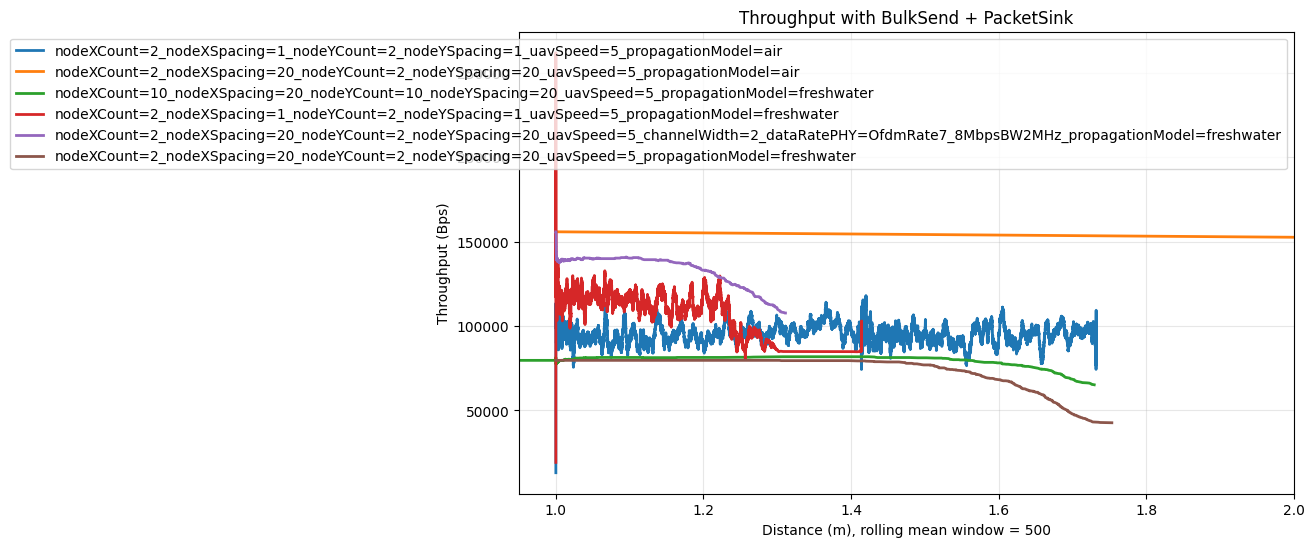

In [47]:
rolling_mean_window_size = 500
plt.figure(figsize=(10, 6))

# Plot rolling averages as solid lines
for i, df in enumerate(throughput):
    plt.plot(df.index, df['Throughput'].rolling(window=rolling_mean_window_size, min_periods=1).mean(), 
             label=scenario_folders[i].name, linewidth=2)

plt.xlabel(f'Distance (m), rolling mean window = {rolling_mean_window_size}')
plt.ylabel('Throughput (Bps)')
plt.title(f'Throughput with BulkSend + PacketSink')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.95, 2)

plt.show()